In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from imblearn.pipeline import Pipeline
import warnings
import time
import os



In [36]:
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["JOBLIB_MULTIPROCESSING"] = "0"

In [37]:
warnings.filterwarnings('ignore')

In [38]:
data_df = pd.read_csv('E:\\PythonCertificates\\Credit Card Fraud Detection\\creditcard.csv\\creditcard.csv')
data_df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [39]:
data_df.shape

(284807, 31)

In [40]:
data_df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

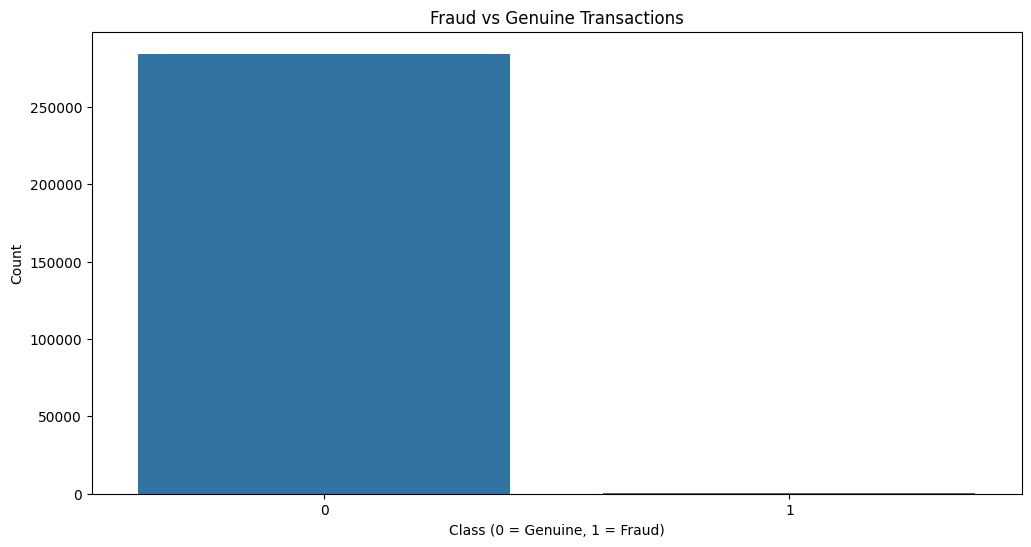

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(x=data_df['Class'].value_counts().index,
            y=data_df['Class'].value_counts().values)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

classes are higly imbalanced

In [42]:
data_df.isna().sum().sort_values(ascending=False)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

there are no null values

In [43]:
X = data_df.drop('Class',axis=1)
y = data_df['Class']

In [44]:
x_train, x_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=365, stratify=y)

In [45]:
def time_to_hour(X):

    X = X.copy()

    X['Hour'] = (X['Time']/3600)%24

    return X.drop('Time',axis=1)

In [46]:
time_transformer = FunctionTransformer(
    time_to_hour,
    validate=False
)

In [47]:
scaling_columns = ['Amount']
scalingpipeline = Pipeline([('scalar', StandardScaler())])

In [48]:
preprocessor = ColumnTransformer(transformers=[('scale', scalingpipeline, scaling_columns)],
    remainder='passthrough')

In [49]:
fullPipelineOfLR = Pipeline(steps=[('time', time_transformer),
                                   ('preprocessor', preprocessor),
                                   ('smote', SMOTE(random_state=365)),
                                   ('model', LogisticRegression())])

In [50]:
# paramOfLR = {'model__C':[0.01,0.1,1,10]}
paramOfLR = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__class_weight': [None, 'balanced']
}

In [51]:
fullPipelineOfRF = Pipeline(steps=[('time', time_transformer),
                                   ('preprocessor', preprocessor),
                                   ('smote', SMOTE(random_state=365)),
                                   ('rfmodel', RandomForestClassifier())])

In [52]:
# paramOfRF = {
#     'rfmodel__n_estimators': [20,50],
#     'rfmodel__max_depth': [3,5],
#     'rfmodel__min_samples_leaf': [5,10]
# }
paramOfRF = {
    'rfmodel__n_estimators': [50, 100],
    'rfmodel__max_depth': [5, 10],
    'rfmodel__min_samples_leaf': [1, 5],
    'rfmodel__class_weight': ['balanced']
}

In [53]:
fullPipelineOfSVM = Pipeline(steps=[
('time',time_transformer),
('preprocess',preprocessor),
('smote',SMOTE(random_state=365)),
('model',
    CalibratedClassifierCV(
        LinearSVC(max_iter=1000),
        cv=3
    )
)
])


In [54]:
# paramOfSVM = {
# 'model__estimator__C':[0.1,1,10],
# }
paramOfSVM = {
    'model__estimator__C': [0.1, 1, 10],
    'model__estimator__class_weight': ['balanced']
}

In [55]:
fullPipelineOfXGBOOST = Pipeline(steps=[
('time',time_transformer),
('preprocess',preprocessor),
('smote',SMOTE(random_state=365)),
('xgmodel',XGBClassifier(use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1]))))
])


In [56]:
# param_xgb = {
# 'xgmodel__n_estimators':[200,300],
# 'xgmodel__max_depth':[3,5],
# 'xgmodel__learning_rate':[0.05,0.1]
# }
param_xgb = {
    'xgmodel__n_estimators': [100, 200],
    'xgmodel__max_depth': [3, 5],
    'xgmodel__learning_rate': [0.01, 0.1],
    'xgmodel__subsample': [0.8, 1.0],
    'xgmodel__colsample_bytree': [0.8, 1.0],
    'xgmodel__scale_pos_weight': [1, 10, 50]
}

In [57]:
def run_grid(pipe,param):
    grid = GridSearchCV(pipe,param,cv=3,scoring='roc_auc',n_jobs=1)
    grid.fit(x_train,y_train)
    best_model = grid.best_estimator_
    y_prob = best_model.predict_proba(x_test)[:,1]
    y_pred = best_model.predict(x_test)
    roc = roc_auc_score(y_test,y_prob)
    report = classification_report(y_test, y_pred)
    confusionmatrix = confusion_matrix(y_test,y_pred)
    f1Score = f1_score(y_test, y_pred)

    return best_model,roc,report,confusionmatrix,f1Score,y_pred

In [58]:
start = time.time()
best_lr,roc_lr,report_lr,confusionmatrix_lr,f1Score_lr,y_pred_lr = run_grid(fullPipelineOfLR,paramOfLR)
end = time.time()
name = "Linear Regression"
print(f"{name} took {(end-start)/60:.2f} minutes")
start = time.time()
best_svm,roc_svm,report_svm,confusionmatrix_svm,f1Score_svm,y_pred_svm  = run_grid(fullPipelineOfSVM,paramOfSVM)
end = time.time()
name = "SVM model"
print(f"{name} took {(end-start)/60:.2f} minutes")
start = time.time()
best_rf,roc_rf,report_rf,confusionmatrix_rf,f1Score_rf,y_pred_rf  = run_grid(fullPipelineOfRF,paramOfRF)
end = time.time()
name = "Random Forest"
print(f"{name} took {(end-start)/60:.2f} minutes")
start = time.time()
best_xgb,roc_xgb,report_xgb,confusionmatrix_xgb,f1Score_xgb,y_pred_xgb = run_grid(fullPipelineOfXGBOOST,param_xgb)
end = time.time()
name = "XGboost"
print(f"{name} took {(end-start)/60:.2f} minutes")

Linear Regression took 0.84 minutes
SVM model took 0.85 minutes
Random Forest took 25.61 minutes
XGboost took 9.67 minutes


In [59]:
results = {

"Logistic Regression":{
    "ROC":roc_lr,
    "F1":f1Score_lr,
    "Report":report_lr,
    "CM":confusionmatrix_lr,
    "y_pred":y_pred_lr
},

"SVM":{
    "ROC":roc_svm,
    "F1":f1Score_svm,
    "Report":report_svm,
    "CM":confusionmatrix_svm,
    "y_pred":y_pred_svm
},

"Random Forest":{
    "ROC":roc_rf,
    "F1":f1Score_rf,
    "Report":report_rf,
    "CM":confusionmatrix_rf,
    "y_pred":y_pred_rf
},

"XGBoost":{
    "ROC":roc_xgb,
    "F1":f1Score_xgb,
    "Report":report_xgb,
    "CM":confusionmatrix_xgb,
    "y_pred":y_pred_xgb
}

}

In [60]:
for model in results:

    print("MODEL:",model)
    print("ROC AUC:",results[model]["ROC"])
    print("F1 Score:",results[model]["F1"])
    print("=====================================")

MODEL: Logistic Regression
ROC AUC: 0.9882307804945276
F1 Score: 0.1157960981749528
MODEL: SVM
ROC AUC: 0.9873407227269074
F1 Score: 0.11514392991239049
MODEL: Random Forest
ROC AUC: 0.9826056512925936
F1 Score: 0.6439393939393939
MODEL: XGBoost
ROC AUC: 0.97739091767827
F1 Score: 0.24233983286908078


In [61]:
for model in results:

    print("MODEL:",model)
    print(results[model]["Report"])
    print("=====================================")

MODEL: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.94      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.96      0.55     56962
weighted avg       1.00      0.98      0.99     56962

MODEL: SVM
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.94      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.96      0.55     56962
weighted avg       1.00      0.98      0.99     56962

MODEL: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.87      0.64        98

    accuracy                           1.00     56962
   macro avg       0.76      0.93      0.82     56962
weighted avg   

MODEL: Logistic Regression


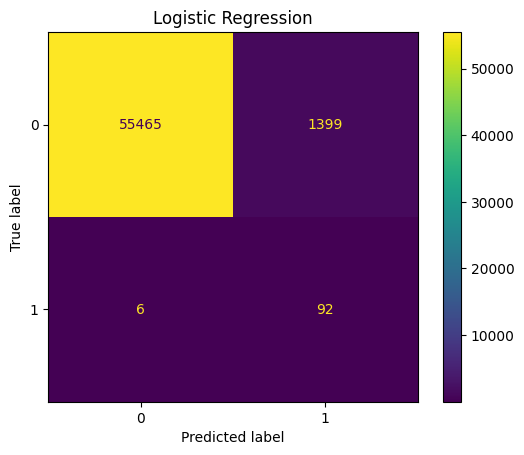

MODEL: SVM


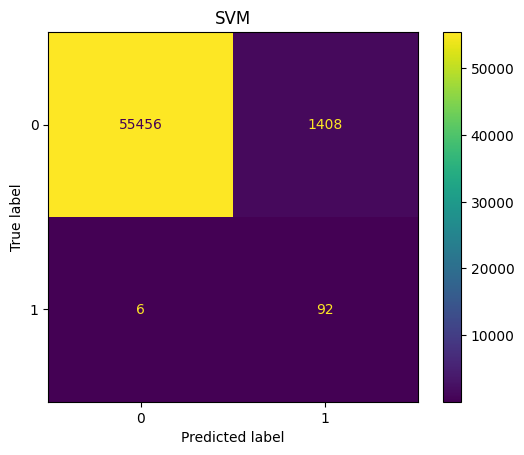

MODEL: Random Forest


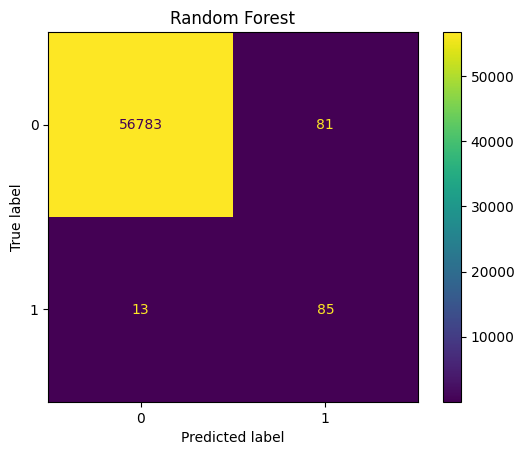

MODEL: XGBoost


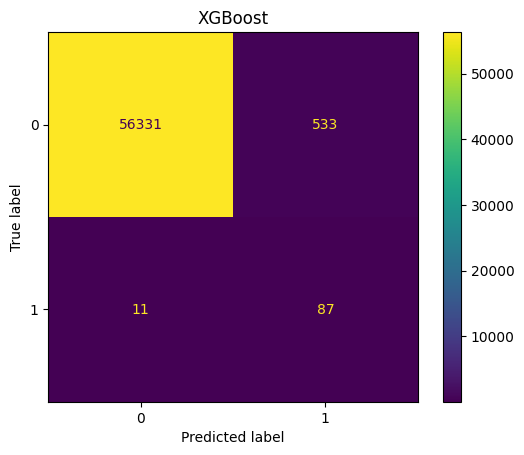

In [62]:
for model in results:

    print("MODEL:",model)

    # ConfusionMatrixDisplay(
    #     confusion_matrix = results[model]["CM"]
    # ).plot()

    ConfusionMatrixDisplay.from_predictions(y_test,results[model]["y_pred"])
    plt.title(model)
    plt.show()

In [63]:
best = max(results,key=lambda x:results[x]['ROC'])

print("BEST MODEL:",best)

BEST MODEL: Logistic Regression


In [64]:
best = max(results,key=lambda x:results[x]['F1'])

print("BEST MODEL:",best)

BEST MODEL: Random Forest


In [65]:
sample_transaction = pd.DataFrame({
    'Time':[100000],
    'V1':[-1.359807],
    'V2':[-0.072781],
    'V3':[2.536347],
    'V4':[1.378155],
    'V5':[-0.338321],
    'V6':[0.462388],
    'V7':[0.239599],
    'V8':[0.098698],
    'V9':[0.363787],
    'V10':[0.090794],
    'V11':[-0.551600],
    'V12':[-0.617801],
    'V13':[-0.991390],
    'V14':[-0.311169],
    'V15':[1.468177],
    'V16':[-0.470401],
    'V17':[0.207971],
    'V18':[0.025791],
    'V19':[0.403993],
    'V20':[0.251412],
    'V21':[-0.018307],
    'V22':[0.277838],
    'V23':[-0.110474],
    'V24':[0.066928],
    'V25':[0.128539],
    'V26':[-0.189115],
    'V27':[0.133558],
    'V28':[-0.021053],
    'Amount':[149.62]
})

In [66]:
prediction = best_rf.predict(sample_transaction)
probability = best_rf.predict_proba(sample_transaction)

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: [0]
Fraud Probability: [[0.94925032 0.05074968]]


In [67]:
fraud_test = pd.DataFrame({
'Time':[406],
'V1':[-2.312227],
'V2':[1.951992],
'V3':[-1.609851],
'V4':[3.997906],
'V5':[-0.522188],
'V6':[-1.426545],
'V7':[-2.537387],
'V8':[1.391657],
'V9':[-2.770089],
'V10':[-2.772272],
'V11':[3.202033],
'V12':[-2.899907],
'V13':[-0.595222],
'V14':[-4.289254],
'V15':[0.389724],
'V16':[-1.140747],
'V17':[-2.830056],
'V18':[-0.016822],
'V19':[0.416956],
'V20':[0.126911],
'V21':[0.517232],
'V22':[-0.035049],
'V23':[-0.465211],
'V24':[0.320198],
'V25':[0.044519],
'V26':[0.177840],
'V27':[0.261145],
'V28':[-0.143276],
'Amount':[0]
})

In [68]:
prediction = best_rf.predict(fraud_test)
probability = best_rf.predict_proba(fraud_test)
print(prediction)
print(probability)

[1]
[[0.05566121 0.94433879]]
